In [1]:
"""
visualisation for Laplacian-eigenvalue hallucination detection.

Implements:
    V1 - Eigenvalue Distribution by Label (KDE)
    V3 - Layer-wise AUROC Profile
    V4 - ROC Curve Comparison Across Datasets
    V5 - Dataset Cross-Generalisation Heatmap

Skipped intentionally:
    V2
    Step 3 (bootstrap statistical validation)
    Step 4 (summary / figure pipeline)

Assumed input:
    A pandas DataFrame with:
      - one row per sample
      - a binary label column
      - a dataset-name column
      - columns for raw top-10 eigenvalue features for all layers/heads
      - optionally a baseline AttentionScore column

Feature naming convention assumed:
    eig_l{layer}_h{head}_k{rank}
where:
    layer in [0, ..., n_layers-1]
    head  in [0, ..., n_heads-1]
    rank  in [1, ..., top_k]

Example:
    eig_l0_h0_k1, eig_l0_h0_k2, ..., eig_l31_h31_k10

"""

from __future__ import annotations

import os
import math
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import seaborn as sns
import os, sys
import torch
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score
import json
from scipy.stats import mannwhitneyu
sys.path.append(os.path.abspath(".."))

from spectral_detection.analysis.visual import *

warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# Configuration
# ============================================================

# DATA_PATH = "df_pca_labelled_or_raw_features.parquet"   # <- change this
OUTPUT_DIR = Path("../data/processed/temp")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Column names in your dataframe
LABEL_COL = "label"             # binary label: 1 = hallucinated, 0 = correct
DATASET_COL = "dataset"         # dataset name: MMLU, TruthfulQA, TriviaQA, HaluEval, NQ-Open
BASELINE_COL = "AttentionScore" # optional baseline column; set to None if absent

# Model / feature layout
N_LAYERS = 21      # change if your model has different number of layers; e.g. 32 for LLaMA-2-7B, 40 for LLaMA-2-13B
N_HEADS = 32       # change if your model has different number of heads
TOP_K = 10

# PCA dimensions from the document:
#   full-feature probe -> 256-dim
#   per-layer probe    -> 64-dim
FULL_PCA_DIM = 256
LAYER_PCA_DIM = 64

TEST_SIZE = 0.2
RANDOM_STATE = 33
N_BOOTSTRAP_ROC = 200  # for ROC confidence bands

In [3]:
print("Loading dataframe...")
DATA_PATH = r"../data/spectral/temp_1/combined_datasets.csv"  
df = load_dataframe(DATA_PATH)

required_meta = [LABEL_COL, DATASET_COL]
for col in required_meta:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

full_feature_cols = build_feature_column_names(N_LAYERS, N_HEADS, TOP_K)
full_feature_cols = get_existing_columns(df, full_feature_cols)
if len(full_feature_cols) == 0:
    raise ValueError(
            "No eigenvalue feature columns found. "
            "Check N_LAYERS / N_HEADS / TOP_K and your naming convention."
        )

print(f"Found {len(full_feature_cols)} raw eigenvalue feature columns.")
print("Datasets:", sorted(df[DATASET_COL].dropna().unique()))

Loading dataframe...
Found 6720 raw eigenvalue feature columns.
Datasets: ['halueval', 'mmlu', 'triviaqa']


Running V1...


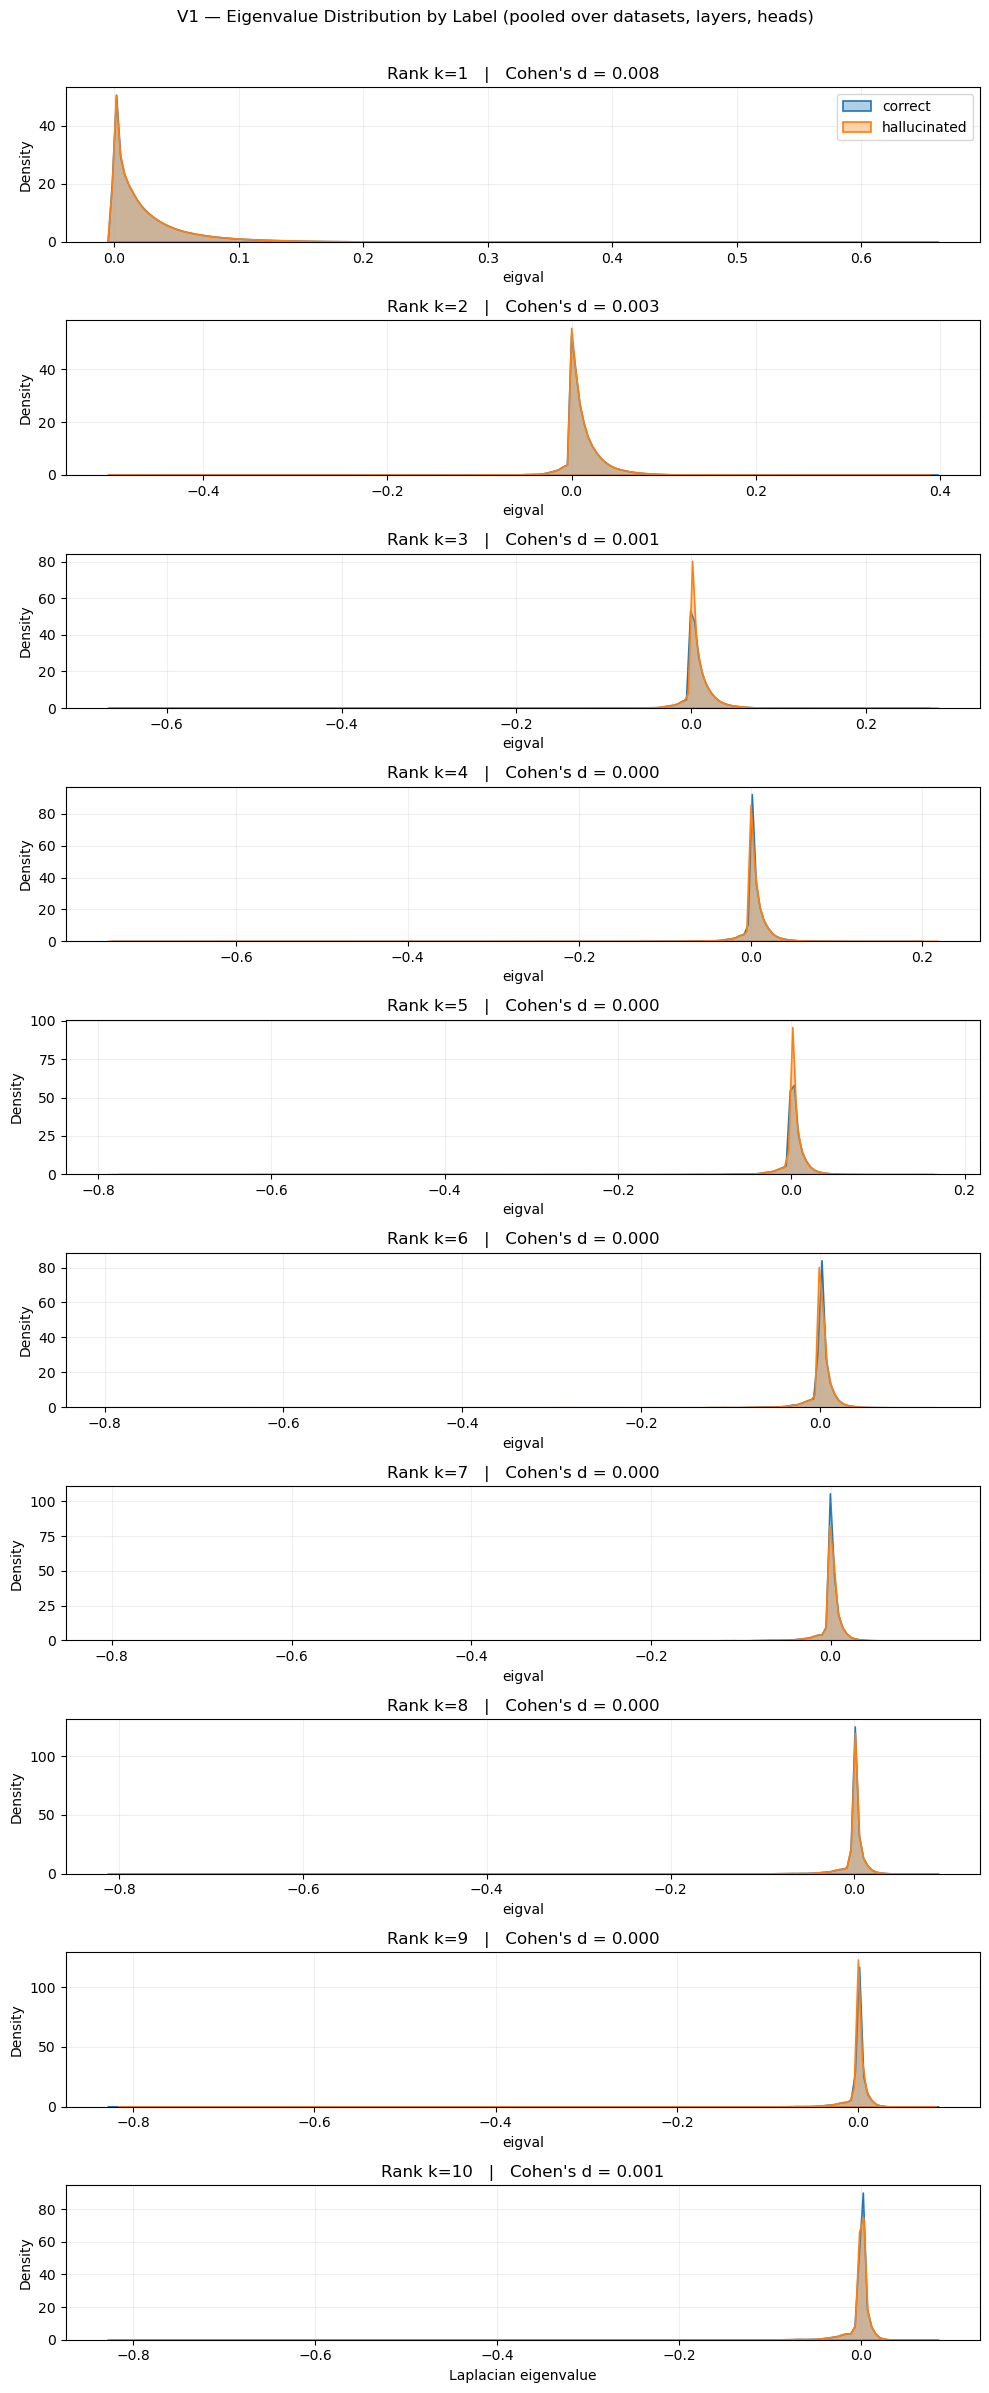

   rank  cohens_d
0     1  0.008320
1     2  0.003074
2     3  0.000753
3     4  0.000159
4     5  0.000025
5     6  0.000088
6     7  0.000175
7     8  0.000317
8     9  0.000445
9    10  0.000586


In [7]:
# -----------------------------
# V1
# -----------------------------
print("Running V1...")
v1_stats = plot_v1_kde_by_rank(
    df=df,
    label_col=LABEL_COL,
    n_layers=N_LAYERS,
    n_heads=N_HEADS,
    top_k=TOP_K,
    output_path=OUTPUT_DIR / "V1_kde_by_rank.png",
)
print(v1_stats)

Running V2...


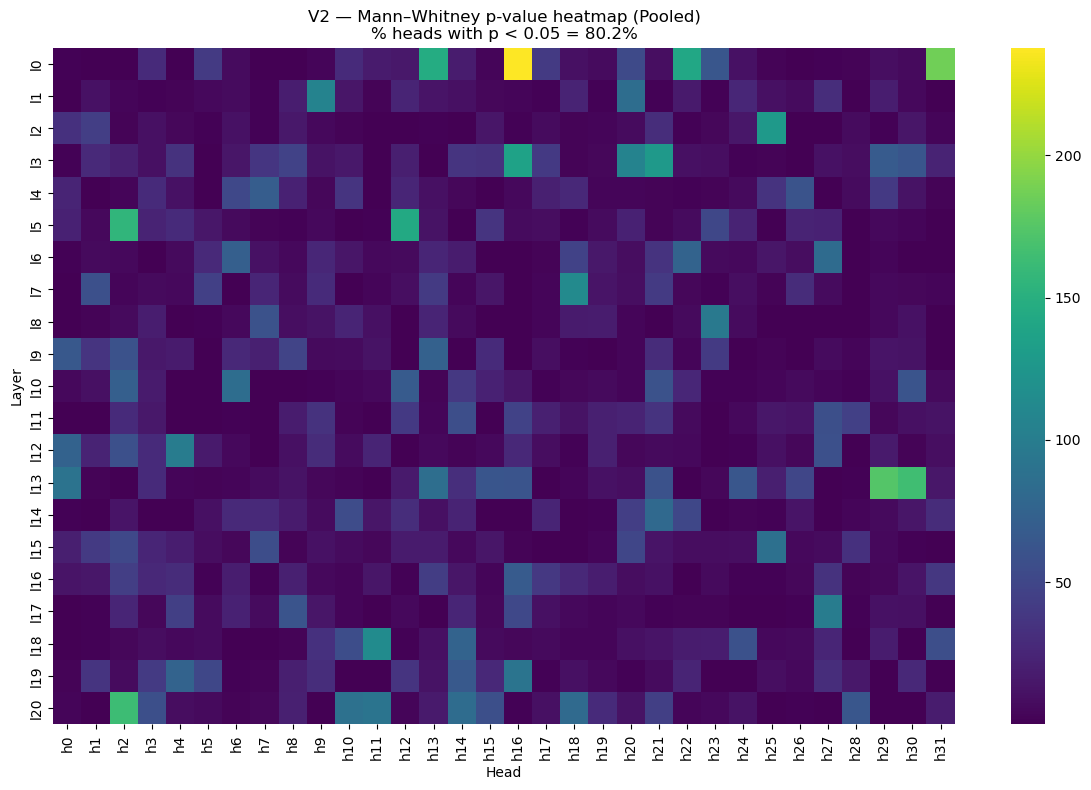

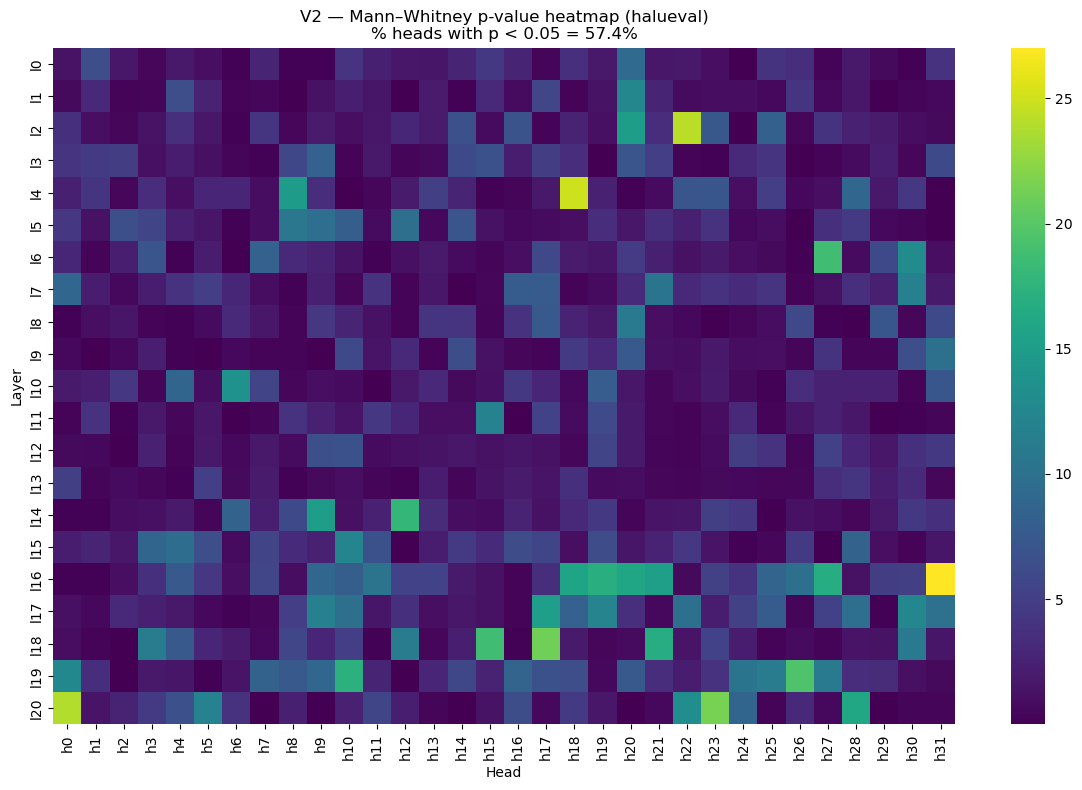

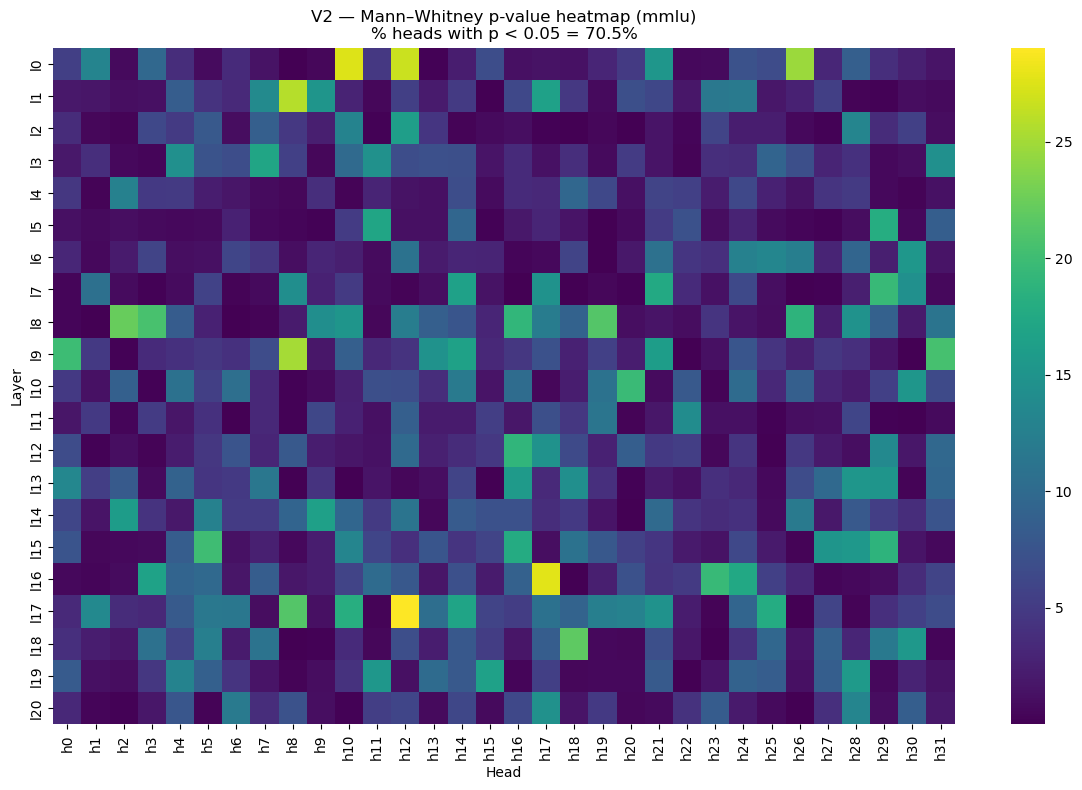

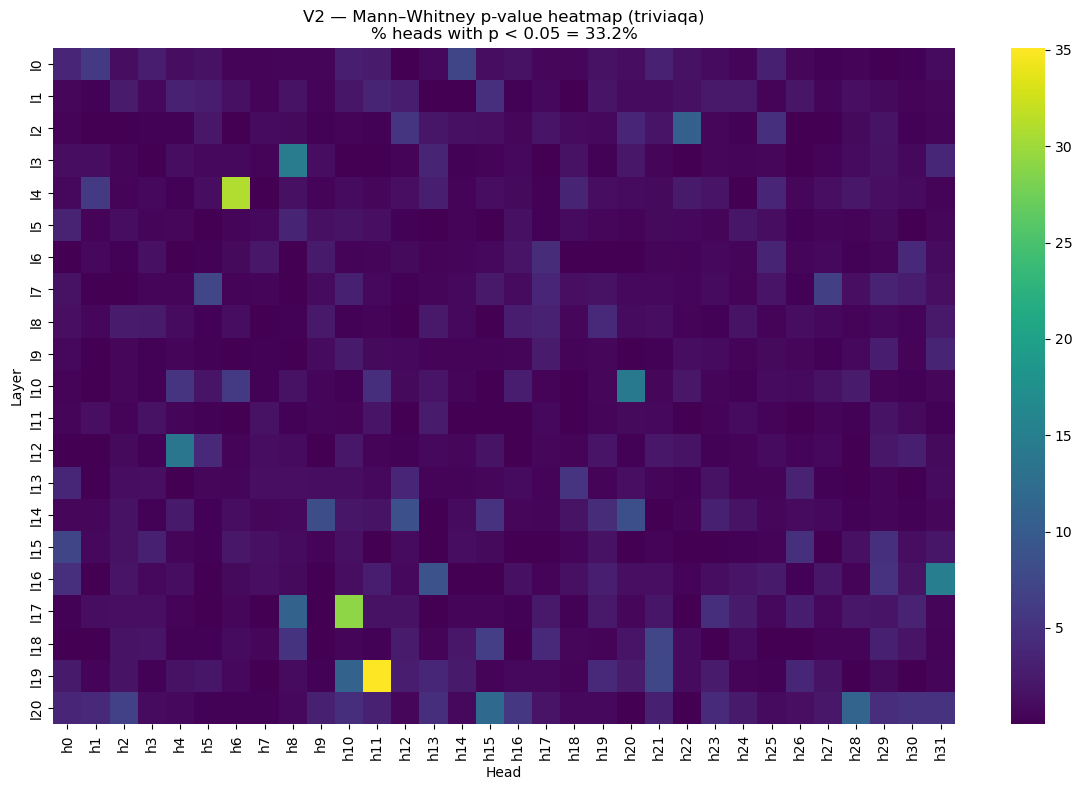


V2 summary:


,dataset,num_significant_heads,total_heads,prop_significant_heads,percent_significant_heads
0,Pooled,539,672,0.802083,80.208333
1,halueval,386,672,0.574405,57.440476
2,mmlu,474,672,0.705357,70.535714
3,triviaqa,223,672,0.331845,33.184524


In [5]:
# -----------------------------
# V2
# -----------------------------
print("Running V2...")
v2_summary = run_v2_all_datasets(
    df=df,
    label_col=LABEL_COL,
    dataset_col=DATASET_COL,
    n_layers=N_LAYERS,
    n_heads=N_HEADS,
    top_k=TOP_K,
    output_dir=OUTPUT_DIR / "V2",
)
plt.show()
print("\nV2 summary:")
v2_summary


Running V3...


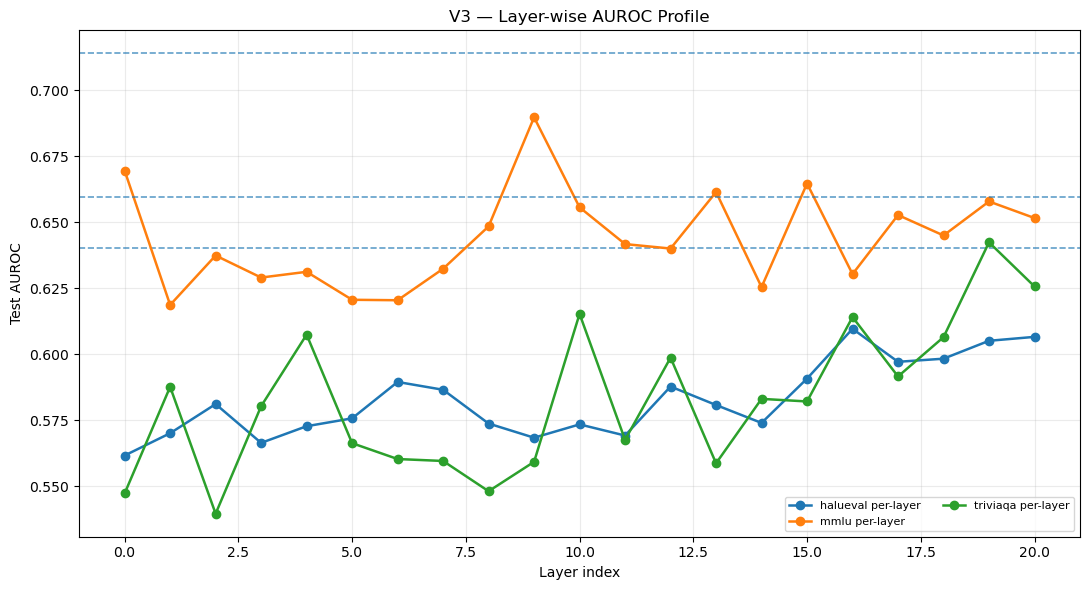

    dataset  layer  layer_auc  all_layer_auc
0  halueval      0   0.561683       0.640498
1  halueval      1   0.570129       0.640498
2  halueval      2   0.581167       0.640498
3  halueval      3   0.566468       0.640498
4  halueval      4   0.572782       0.640498


In [4]:
# -----------------------------
# V3
# -----------------------------
print("Running V3...")
v3_stats = plot_v3_layerwise_auroc(
    df=df,
    label_col=LABEL_COL,
    dataset_col=DATASET_COL,
    n_layers=N_LAYERS,
    n_heads=N_HEADS,
    top_k=TOP_K,
    full_pca_dim=FULL_PCA_DIM,
    layer_pca_dim=LAYER_PCA_DIM,
    test_size=TEST_SIZE,
    output_path=OUTPUT_DIR / "V3_layerwise_auroc.png",
)
print(v3_stats.head())

Running V4...


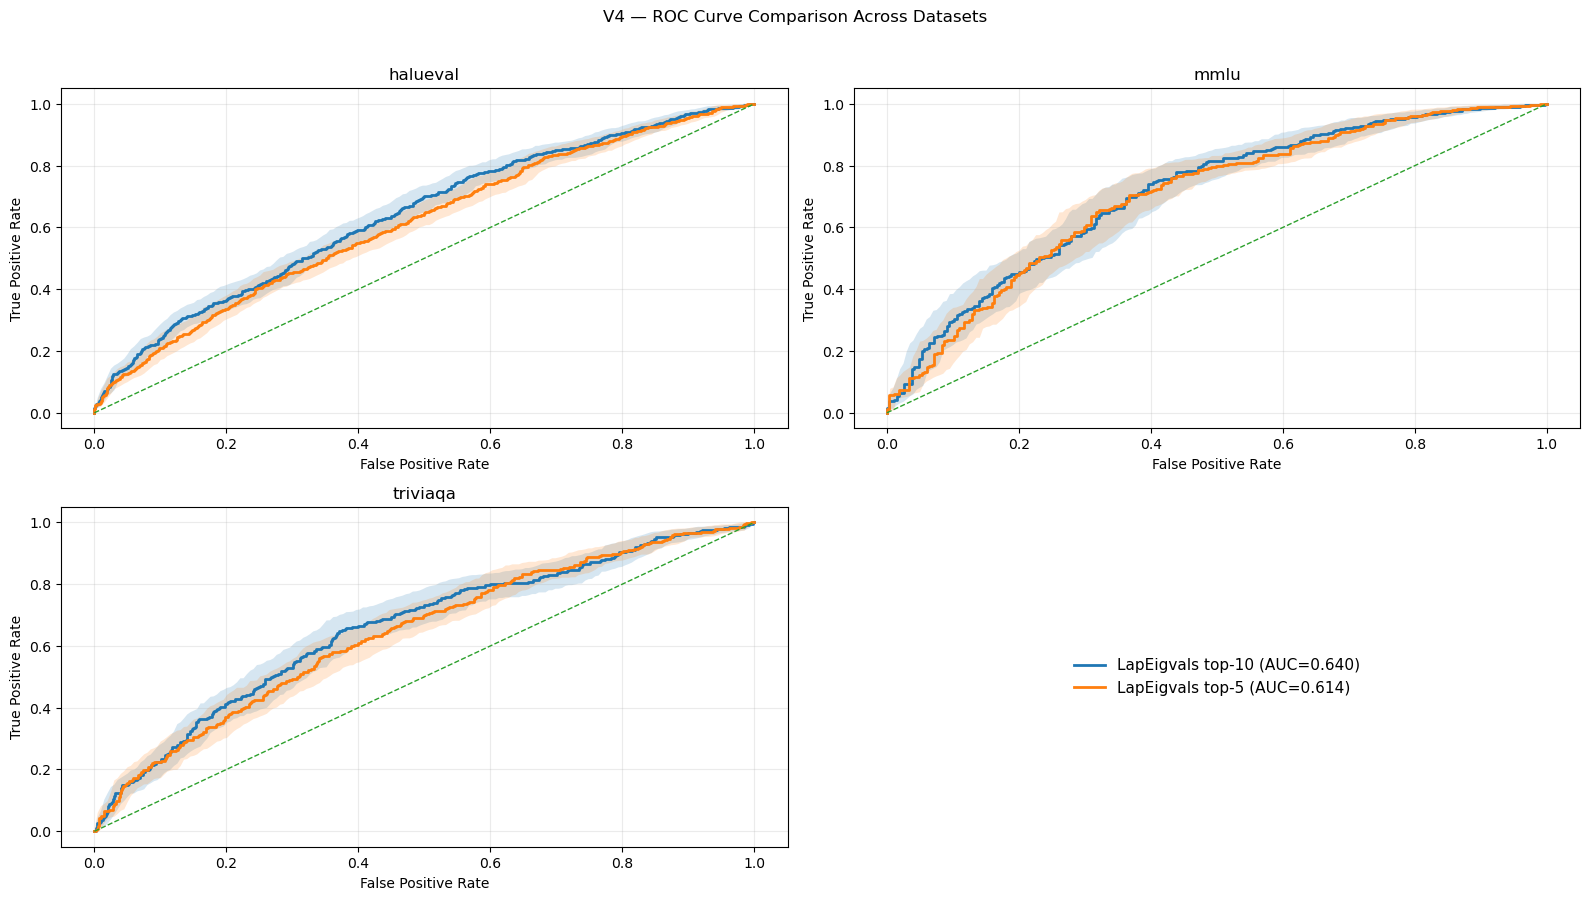

    dataset  auc_lapeig_top10  auc_attentionscore  auc_lapeig_top5
0  halueval          0.640498                 NaN         0.613634
1      mmlu          0.714065                 NaN         0.703858
2  triviaqa          0.659748                 NaN         0.642377


In [5]:
# -----------------------------
# V4
# -----------------------------
print("Running V4...")
v4_stats = plot_v4_roc_comparison(
    df=df,
    label_col=LABEL_COL,
    dataset_col=DATASET_COL,
    baseline_col=BASELINE_COL,
    n_layers=N_LAYERS,
    n_heads=N_HEADS,
    top_k=TOP_K,
    full_pca_dim=FULL_PCA_DIM,
    output_path=OUTPUT_DIR / "V4_roc_comparison.png",
)
print(v4_stats)

Running V5...


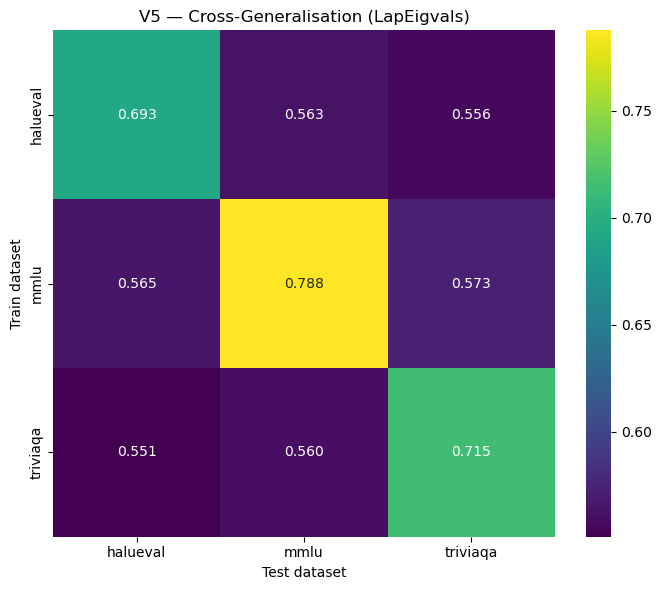


LapEigvals cross-generalisation matrix:
          halueval      mmlu  triviaqa
halueval  0.692860  0.562620  0.555777
mmlu      0.564680  0.787564  0.572624
triviaqa  0.550816  0.559659  0.715107


In [6]:
# -----------------------------
# V5
# -----------------------------
print("Running V5...")
lapeig_mat = plot_v5_cross_generalisation(
    df=df,
    dataset_col=DATASET_COL,
    label_col=LABEL_COL,
    n_layers=N_LAYERS,
    n_heads=N_HEADS,
    top_k=TOP_K,
    full_pca_dim=FULL_PCA_DIM,
    output_path=OUTPUT_DIR / "V5_cross_generalisation.png",
)
print("\nLapEigvals cross-generalisation matrix:")
print(lapeig_mat)

Running bootstrap validation...


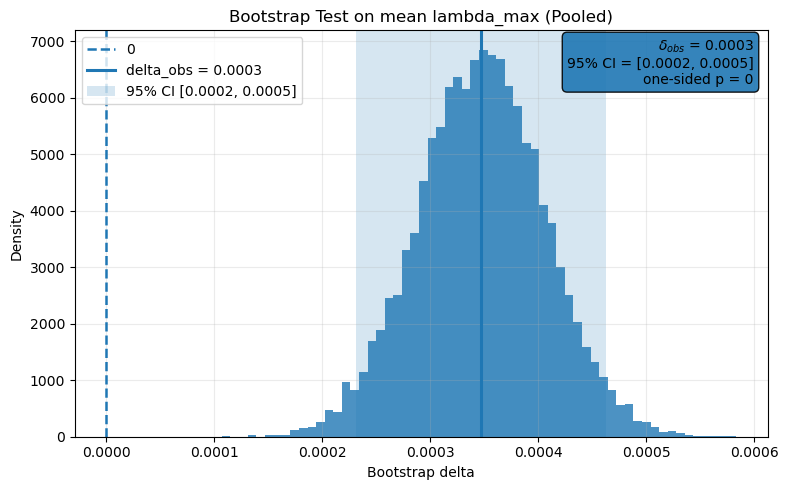

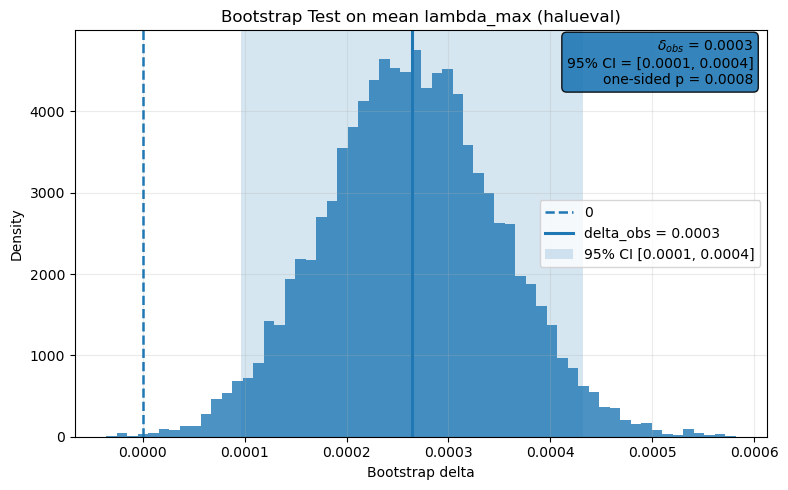

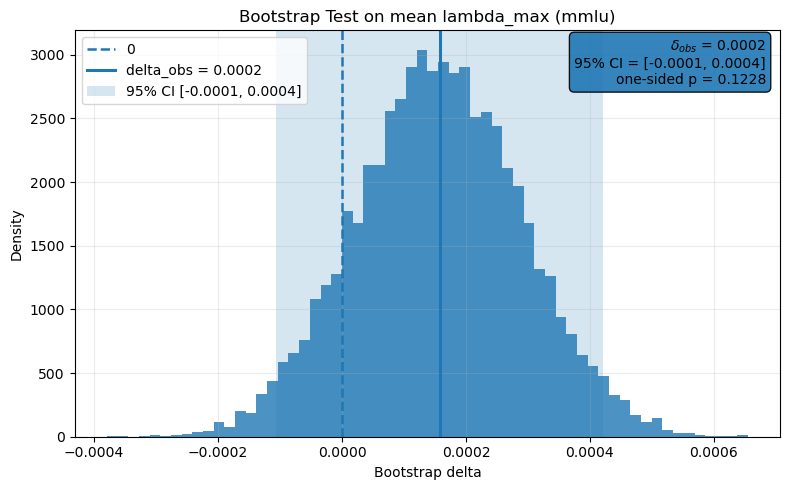

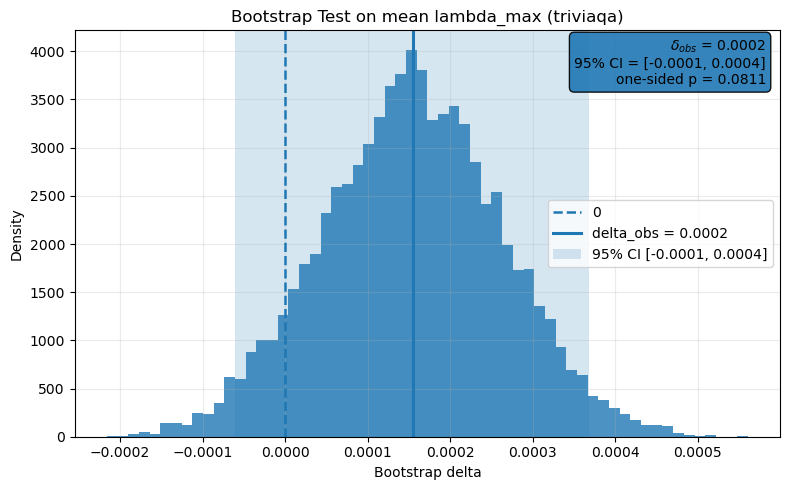


Bootstrap summary:


,dataset,delta_obs,ci_low_95,ci_high_95,p_value_one_sided,n_samples,n_hallucinated,n_correct
0,Pooled,0.000347,0.000231,0.000463,0.0000,20000,9011,10989
1,halueval,0.000265,0.000096,0.000432,0.0008,10000,3182,6818
2,mmlu,0.000157,-0.000106,0.000421,0.1228,5000,3673,1327
3,triviaqa,0.000155,-0.000061,0.000368,0.0811,5000,2156,2844


In [8]:
# -----------------------------
# Statistical Validation via Bootstrap
# -----------------------------
BOOTSTRAP_B = 10000
print("Running bootstrap validation...")
bootstrap_df = run_bootstrap_validation(
    df=df,
    label_col=LABEL_COL,
    dataset_col=DATASET_COL,
    n_layers=N_LAYERS,
    n_heads=N_HEADS,
    output_dir=OUTPUT_DIR / "bootstrap",
    B=BOOTSTRAP_B,
    random_state=RANDOM_STATE,
)

print("\nBootstrap summary:")
bootstrap_df